In [7]:
import os
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from dotenv import load_dotenv
from scipy.sparse import hstack, csr_matrix
from scipy.sparse.linalg import svds
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

# --- 1. CẤU HÌNH VÀ KẾT NỐI DỮ LIỆU ---
warnings.filterwarnings('ignore')
load_dotenv()

server = os.getenv("server_name")
database = os.getenv("db_name")
user = os.getenv("username")
password = os.getenv("password")

conn_str = (
    f'DRIVER={{ODBC Driver 18 for SQL Server}};'
    f'SERVER={server};DATABASE={database};'
    f'UID={user};PWD={password};'
    f'Encrypt=yes;TrustServerCertificate=yes;'
)

try:
    conn = pyodbc.connect(conn_str)
    query = """
    SELECT 
        s.order_id, s.order_date, s.quantity, s.sales, s.profit,
        c.customer_id, c.gender, c.annual_income, c.occupation,
        DATEDIFF(YEAR, c.birth_date, GETDATE()) AS age,
        p.product_code, p.product, p.category, p.subcategory,
        r.city, r.country, r.market
    FROM e_commerce.ecom_sales s
    JOIN e_commerce.customer c ON s.customer_id = c.customer_id
    JOIN e_commerce.product p ON s.product_code = p.product_code
    JOIN e_commerce.region r ON s.region_code = r.region_code;
    """
    df = pd.read_sql(query, conn)
    print(f"Tải dữ liệu thành công: {len(df)} dòng.")
except Exception as e:
    print(f"Lỗi kết nối: {e}")

Tải dữ liệu thành công: 51287 dòng.


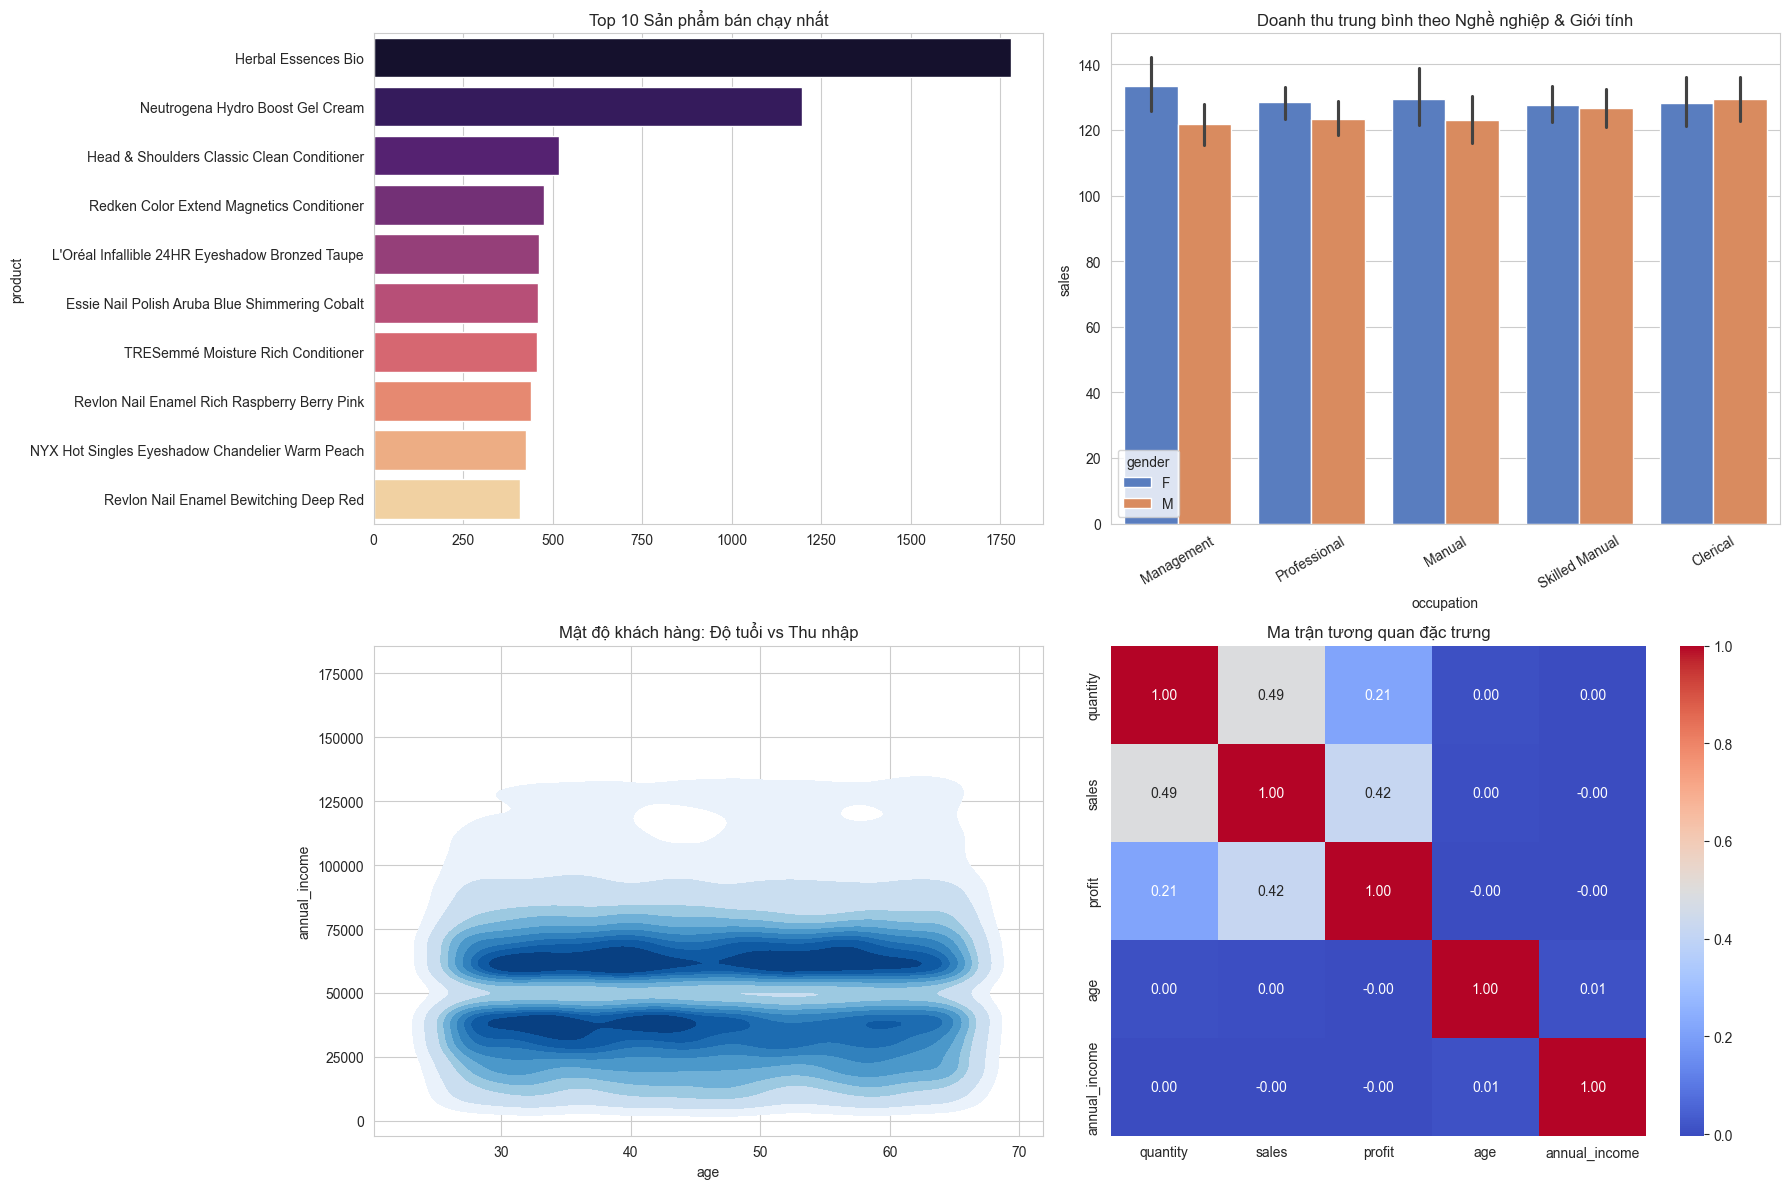

In [8]:
# --- 2. PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA) ---
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top 10 sản phẩm bán chạy theo số lượng
top_products = df.groupby('product')['quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index, ax=axes[0, 0], palette='magma')
axes[0, 0].set_title('Top 10 Sản phẩm bán chạy nhất')

# Doanh thu trung bình theo Nghề nghiệp & Giới tính
sns.barplot(data=df, x='occupation', y='sales', hue='gender', ax=axes[0, 1], palette='muted')
axes[0, 1].set_title('Doanh thu trung bình theo Nghề nghiệp & Giới tính')
axes[0, 1].tick_params(axis='x', rotation=30)

# Mật độ phân bố Độ tuổi và Thu nhập
sns.kdeplot(data=df, x='age', y='annual_income', fill=True, cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Mật độ khách hàng: Độ tuổi vs Thu nhập')

# Ma trận tương quan giữa các biến số
numeric_cols = ['quantity', 'sales', 'profit', 'age', 'annual_income']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('Ma trận tương quan đặc trưng')
plt.tight_layout()

In [9]:
# --- 3. PHÂN TÍCH ĐỘ THƯA (SPARSITY) ---
n_users = df['customer_id'].nunique()
n_items = df['product_code'].nunique()
n_interactions = len(df.groupby(['customer_id', 'product_code']))
sparsity = (1 - n_interactions / (n_users * n_items)) * 100
print(f"Độ thưa dữ liệu (Sparsity): {sparsity:.2f}%")

Độ thưa dữ liệu (Sparsity): 99.92%


In [10]:
# --- 4. CHIA DỮ LIỆU TRAIN/TEST ---
# Chia ngẫu nhiên 80/20 để đảm bảo đủ mẫu khách hàng quay lại cho đánh giá
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# --- 5. XỬ LÝ ĐẶC TRƯNG SẢN PHẨM (CONTENT-BASED) ---
# Tạo danh mục sản phẩm duy nhất từ tập train
item_features = train_df[['product_code', 'product', 'category', 'subcategory']].drop_duplicates().reset_index(drop=True)

# TF-IDF cho tên sản phẩm (loại bỏ từ dừng tiếng Anh)
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(item_features['product'])

# One-Hot Encoding cho danh mục và tiểu mục
encoder = OneHotEncoder()
cat_encoded = encoder.fit_transform(item_features[['category', 'subcategory']])

# Ghép các ma trận lại thành hồ sơ sản phẩm (Item Profile)
item_profiles = hstack([tfidf_matrix, cat_encoded])

In [11]:
# --- 6. PHÂN RÃ MA TRẬN (COLLABORATIVE FILTERING) ---
# Tạo ma trận User-Item từ tập train
user_item_pivot = train_df.pivot_table(index='customer_id', columns='product_code', values='quantity').fillna(0)
user_item_sparse = csr_matrix(user_item_pivot.values)

# Thực hiện SVD để tìm các yếu tố ẩn (k=50)
U, sigma, Vt = svds(user_item_sparse, k=50)
sigma = np.diag(sigma)
# Tái tạo ma trận dự đoán rating
predicted_ratings = np.dot(np.dot(U, sigma), Vt)
preds_df = pd.DataFrame(predicted_ratings, columns=user_item_pivot.columns, index=user_item_pivot.index)

# --- 7. XÂY DỰNG MÔ HÌNH HYBRID ---
def hybrid_recommender(customer_id, product_code, alpha=0.4):
    # Nhánh Content-based: Tính độ tương đồng Cosine
    product_idx = item_features.index[item_features['product_code'] == product_code].tolist()[0]
    content_sim = cosine_similarity(item_profiles[product_idx], item_profiles).flatten()
    
    content_scores = pd.DataFrame({
        'product_code': item_features['product_code'],
        'content_score': content_sim
    })

    # Nhánh Collaborative Filtering: Lấy điểm dự đoán của User
    user_idx = user_item_pivot.index.get_loc(customer_id)
    cf_preds = preds_df.iloc[user_idx]
    
    # Chuẩn hóa điểm CF về đoạn [0, 1]
    scaler = MinMaxScaler()
    cf_preds_scaled = scaler.fit_transform(cf_preds.values.reshape(-1, 1)).flatten()
    
    cf_scores = pd.DataFrame({
        'product_code': user_item_pivot.columns,
        'cf_score': cf_preds_scaled
    })

    # Kết hợp hai nhánh theo trọng số alpha
    hybrid_df = pd.merge(content_scores, cf_scores, on='product_code')
    hybrid_df['final_score'] = (alpha * hybrid_df['content_score']) + ((1 - alpha) * hybrid_df['cf_score'])
    
    # Loại bỏ sản phẩm đang xem và lấy Top 5 gợi ý
    recommendations = hybrid_df[hybrid_df['product_code'] != product_code]
    recommendations = recommendations.sort_values(by='final_score', ascending=False).head(5)
    
    return pd.merge(recommendations, item_features, on='product_code')[['product_code', 'product', 'category', 'final_score']]

In [12]:
# --- 8. ĐÁNH GIÁ MÔ HÌNH (CATEGORY PRECISION) ---
def evaluate_model(test_data):
    # Lấy danh sách khách hàng chung giữa train và test
    common_customers = list(set(train_df['customer_id']).intersection(set(test_data['customer_id'])))
    hits = 0
    valid_count = 0
    
    for customer_id in common_customers:
        # Kiểm tra khách hàng có lịch sử trong train không
        history = train_df[train_df['customer_id'] == customer_id]
        if history.empty: continue
            
        last_prod = history['product_code'].iloc[-1]
        # Bỏ qua nếu mã sản phẩm không tồn tại trong danh mục train
        if last_prod not in item_features['product_code'].values: continue
            
        # Danh mục thực tế khách đã mua trong tương lai (tập test)
        actual_categories = set(test_data[test_data['customer_id'] == customer_id]['category'])
        
        try:
            # Lấy gợi ý từ mô hình Hybrid
            recs = hybrid_recommender(customer_id, last_prod)
            # Kiểm tra nếu có ít nhất 1 danh mục gợi ý trùng với thực tế
            if len(actual_categories.intersection(set(recs['category']))) > 0:
                hits += 1
            valid_count += 1
        except:
            continue
            
    return (hits / valid_count * 100) if valid_count > 0 else 0

# Xuất kết quả đánh giá cuối cùng
precision_rate = evaluate_model(test_df)
print(f"Kết quả Category Precision Rate: {precision_rate:.2f}%")

Kết quả Category Precision Rate: 66.77%
